# Day 1 — SQL, Delta Lake, and Evidence Investigation

**Outcome:** participants understand the data model, query connected tables, identify data-quality contradictions, and explain why trustworthy AI starts with trustworthy evidence.

In [0]:
CATALOG = spark.sql("SELECT current_catalog()").first()[0]
SCHEMA = "v2_nuclear_enterprise_360"
spark.sql(f"USE CATALOG `{CATALOG}`")
spark.sql(f"USE SCHEMA `{SCHEMA}`")
print(f"Using {CATALOG}.{SCHEMA}")

Using workspace.v2_nuclear_enterprise_360


In [0]:
# Create dropdown widget for asset selection
import pandas as pd

# Fetch all asset names for the dropdown
asset_names = [row.asset_name for row in spark.sql("SELECT DISTINCT asset_name FROM asset_360 ORDER BY asset_name").collect()]

# Create the dropdown widget
dbutils.widgets.dropdown("selected_asset", asset_names[0], asset_names)

print(f"Asset dropdown created with {len(asset_names)} options. Default: {asset_names[0]}")

Asset dropdown created with 128 options. Default: Compressor 006


## 1. Explore the lakehouse

In [0]:
display(spark.sql("SHOW TABLES"))

database,tableName,isTemporary
v2_nuclear_enterprise_360,a001_source_document_links,false
v2_nuclear_enterprise_360,a001_source_documents,false
v2_nuclear_enterprise_360,actions,false
v2_nuclear_enterprise_360,agent_runs,false
v2_nuclear_enterprise_360,agent_tool_calls,false
v2_nuclear_enterprise_360,asset_360,false
v2_nuclear_enterprise_360,asset_health_scores,false
v2_nuclear_enterprise_360,assets,false
v2_nuclear_enterprise_360,dataset_metadata,false
v2_nuclear_enterprise_360,departments,false


In [0]:
%sql
DESCRIBE EXTENDED assets;

col_name,data_type,comment
asset_id,string,null
system_id,string,null
asset_name,string,null
asset_type,string,null
criticality,string,null
manufacturer,string,null
installation_date,string,null
status,string,null
maintenance_interval_days,bigint,null
,,


## 2. Asset 360 investigation

Find high-criticality assets that combine a low health score, open high-priority work, and inspection follow-up.

In [0]:
%sql
SELECT asset_id, asset_name, system_name, criticality,
       health_score, risk_level, high_priority_open_work,
       follow_up_findings, recommended_action
FROM asset_360
WHERE criticality = 'HIGH'
  AND (risk_level IN ('HIGH','MEDIUM') OR high_priority_open_work > 0)
ORDER BY health_score, high_priority_open_work DESC;

asset_id,asset_name,system_name,criticality,health_score,risk_level,high_priority_open_work,follow_up_findings,recommended_action
A-001,Pump 001,Cooling Water,HIGH,68.05,MEDIUM,3,2,Increase monitoring
A-033,Pump 033,Cooling Water,HIGH,77.12,MEDIUM,1,2,Increase monitoring
A-044,Heat Exchanger 044,Electrical Distribution,HIGH,92.13,LOW,1,4,Continue routine monitoring
A-094,Compressor 094,Water Treatment,HIGH,92.15,LOW,1,1,Continue routine monitoring
A-070,Compressor 070,Cooling Water,HIGH,92.16,LOW,1,0,Continue routine monitoring
A-012,Heat Exchanger 012,Electrical Distribution,HIGH,92.19,LOW,1,1,Continue routine monitoring
A-063,Transformer 063,Water Treatment,HIGH,92.8,LOW,1,2,Continue routine monitoring
A-008,Filter 008,Cooling Water,HIGH,93.3,LOW,1,0,Continue routine monitoring
A-097,Pump 097,Cooling Water,HIGH,93.36,LOW,2,3,Continue routine monitoring
A-065,Pump 065,Cooling Water,HIGH,93.37,LOW,2,1,Continue routine monitoring


In [0]:
%sql
SELECT system_name, risk_level, COUNT(*) AS asset_count
FROM asset_360
GROUP BY system_name, risk_level
ORDER BY system_name, risk_level;

system_name,risk_level,asset_count
Cooling Water,LOW,30
Cooling Water,MEDIUM,2
Electrical Distribution,LOW,32
Ventilation,LOW,32
Water Treatment,LOW,32


### Trend evidence for the mystery asset

In [0]:
%sql
SELECT DATE(reading_timestamp) AS reading_date,
       ROUND(AVG(vibration_mm_s), 3) AS average_vibration,
       ROUND(AVG(temperature_c), 2) AS average_temperature,
       SUM(anomaly_flag) AS anomalies,
       SUM(CASE WHEN sensor_quality <> 'GOOD' THEN 1 ELSE 0 END) AS suspect_readings
FROM sensor_readings
WHERE asset_id = 'A-001'
GROUP BY DATE(reading_timestamp)
ORDER BY reading_date;

reading_date,average_vibration,average_temperature,anomalies,suspect_readings
2026-05-28,1.32,52.9,0,0
2026-05-29,1.357,53.28,0,0
2026-05-30,1.483,53.09,0,1
2026-05-31,1.485,53.32,0,0
2026-06-01,1.446,52.92,0,0
2026-06-02,1.428,53.67,0,0
2026-06-03,1.51,52.71,0,1
2026-06-04,1.477,54.09,0,0
2026-06-05,1.436,53.1,0,0
2026-06-06,1.43,53.54,0,0


In [0]:
%sql
-- Weekly, monthly, and yearly summary of anomalies and suspect readings for asset A-001

SELECT 'WEEKLY' AS granularity,
       YEAR(reading_timestamp)  AS yr,
       MONTH(reading_timestamp) AS mon,
       WEEKOFYEAR(reading_timestamp)  AS wk,
       SUM(anomaly_flag) AS anomalies,
       SUM(CASE WHEN sensor_quality <> 'GOOD' THEN 1 ELSE 0 END) AS suspect_readings
FROM sensor_readings
WHERE asset_id = 'A-001'
GROUP BY YEAR(reading_timestamp), MONTH(reading_timestamp), WEEKOFYEAR(reading_timestamp)

UNION ALL

SELECT 'MONTHLY' AS granularity,
       YEAR(reading_timestamp)  AS yr,
       MONTH(reading_timestamp) AS mon,
       NULL                     AS wk,
       SUM(anomaly_flag) AS anomalies,
       SUM(CASE WHEN sensor_quality <> 'GOOD' THEN 1 ELSE 0 END) AS suspect_readings
FROM sensor_readings
WHERE asset_id = 'A-001'
GROUP BY YEAR(reading_timestamp), MONTH(reading_timestamp)

UNION ALL

SELECT 'YEARLY' AS granularity,
       YEAR(reading_timestamp)  AS yr,
       NULL                     AS mon,
       NULL                     AS wk,
       SUM(anomaly_flag) AS anomalies,
       SUM(CASE WHEN sensor_quality <> 'GOOD' THEN 1 ELSE 0 END) AS suspect_readings
FROM sensor_readings
WHERE asset_id = 'A-001'
GROUP BY YEAR(reading_timestamp)

ORDER BY granularity, yr, mon, wk;

granularity,yr,mon,wk,anomalies,suspect_readings
MONTHLY,2026,5,null,0,1
MONTHLY,2026,6,null,0,5
MONTHLY,2026,7,null,0,6
MONTHLY,2026,8,null,23,2
WEEKLY,2026,5,22,0,1
WEEKLY,2026,6,23,0,1
WEEKLY,2026,6,24,0,3
WEEKLY,2026,6,25,0,0
WEEKLY,2026,6,26,0,1
WEEKLY,2026,6,27,0,0


Use the result visualization control to create a line chart. Ask participants: **Does an increasing trend prove a failure, or only justify further review?**

## 3. Project risk investigation

In [0]:
%sql
SELECT p.project_id, p.project_name, p.status,
       r.risk_id, r.risk_category, r.risk_description,
       r.exposure_score, r.owner_employee_id,
       r.target_date, r.status AS risk_status
FROM projects p
JOIN risks r ON p.project_id = r.project_id
WHERE r.status IN ('OPEN','MITIGATING')
  AND r.exposure_score >= 15
ORDER BY r.exposure_score DESC, r.target_date;

project_id,project_name,status,risk_id,risk_category,risk_description,exposure_score,owner_employee_id,target_date,risk_status
P-028,Document Modernization 28,ON_TRACK,R-0322,COST,Supplier dependency may increase lead time.,25,E-087,2026-06-28,MITIGATING
P-004,Knowledge Management 04,AT_RISK,R-0353,PEOPLE,Required stakeholder review may not complete before milestone.,25,E-237,2026-08-02,OPEN
P-024,Knowledge Management 24,ON_TRACK,R-0039,SCHEDULE,Current document version may be unclear to project users.,25,E-018,2026-08-12,MITIGATING
P-017,Analytics Enablement 17,DELAYED,R-0140,DATA,Data quality may delay analytics validation.,25,E-141,2026-08-18,MITIGATING
P-001,Enterprise Knowledge and Risk Intelligence Pilot,AT_RISK,R-0001,DATA,Conflicting document versions may cause the agent to cite an unapproved instruction.,25,E-002,2026-09-08,OPEN
P-003,Training Digitization 03,ON_TRACK,R-0235,DATA,Resource availability may affect delivery schedule.,25,E-093,2026-10-26,OPEN
P-013,Document Modernization 13,COMPLETED,R-0334,SCHEDULE,Current document version may be unclear to project users.,25,E-115,2026-11-11,MITIGATING
P-001,Enterprise Knowledge and Risk Intelligence Pilot,AT_RISK,R-0283,TECHNOLOGY,Required stakeholder review may not complete before milestone.,25,E-024,2026-11-16,OPEN
P-012,Document Modernization 12,AT_RISK,R-0016,QUALITY,Resource availability may affect delivery schedule.,25,E-194,2026-12-30,MITIGATING
P-010,Document Modernization 10,AT_RISK,R-0169,PEOPLE,AI response quality may be insufficient without evaluation data.,25,E-021,2027-01-01,OPEN


## 4. Evidence contradictions

These are intentionally planted. Participants should explain why each contradiction matters to an AI agent.

In [0]:
%sql
-- Completed work with missing completion evidence
SELECT work_order_id, asset_id, status, completed_date, actual_hours, problem_description
FROM work_orders
WHERE status = 'COMPLETED'
  AND completed_date IS NULL;

work_order_id,asset_id,status,completed_date,actual_hours,problem_description
WO-00002,A-002,COMPLETED,null,4.5,Work recorded as complete but closure evidence and completion date are missing.


In [0]:
%sql
-- Completed actions without an evidence reference
SELECT action_id, project_id, risk_id, status, completed_date, evidence_reference
FROM actions
WHERE status = 'COMPLETED'
  AND evidence_reference IS NULL;

action_id,project_id,risk_id,status,completed_date,evidence_reference
ACT-0003,P-001,R-0001,COMPLETED,2026-08-24,null


In [0]:
%sql
-- High-exposure risks without an accountable owner
SELECT risk_id, project_id, risk_description, exposure_score, target_date
FROM risks
WHERE status IN ('OPEN','MITIGATING')
  AND exposure_score >= 15
  AND owner_employee_id IS NULL;

risk_id,project_id,risk_description,exposure_score,target_date
R-0002,P-001,High-exposure AI workflow risk has no assigned owner.,20,2026-08-15


In [0]:
%sql
-- Open urgent work assigned to an employee with an expired relevant qualification
SELECT w.work_order_id, w.asset_id, w.priority, w.assigned_employee_id,
       t.course_name, t.expiry_date, t.qualification_status
FROM work_orders w
JOIN training_records t ON w.assigned_employee_id = t.employee_id
WHERE w.status IN ('OPEN','IN_PROGRESS')
  AND w.priority IN ('HIGH','URGENT')
  AND t.qualification_status = 'EXPIRED';

work_order_id,asset_id,priority,assigned_employee_id,course_name,expiry_date,qualification_status
WO-00001,A-001,URGENT,E-001,Work Management Fundamentals,2025-01-10,EXPIRED
WO-00004,A-034,URGENT,E-082,Human-in-the-Loop Review,2026-03-29,EXPIRED
WO-00009,A-091,HIGH,E-129,Document Control,2026-06-07,EXPIRED
WO-00027,A-095,URGENT,E-080,Document Control,2026-04-09,EXPIRED
WO-00044,A-110,HIGH,E-002,Work Management Fundamentals,2026-03-08,EXPIRED
WO-00059,A-063,HIGH,E-015,Enterprise Data Handling,2026-03-23,EXPIRED
WO-00081,A-108,HIGH,E-099,Responsible AI Foundations,2026-04-08,EXPIRED
WO-00083,A-104,HIGH,E-015,Enterprise Data Handling,2026-03-23,EXPIRED
WO-00087,A-039,HIGH,E-205,Enterprise Data Handling,2026-05-01,EXPIRED
WO-00194,A-111,HIGH,E-125,Work Management Fundamentals,2026-07-01,EXPIRED


In [0]:
# Get row counts for all tables in the schema
tables = spark.sql("SHOW TABLES").collect()

row_counts = []
for table in tables:
    table_name = table.tableName
    count = spark.table(table_name).count()
    row_counts.append((table_name, count))

# Display results
from pyspark.sql import Row
result_df = spark.createDataFrame([Row(table_name=name, row_count=count) for name, count in row_counts])
display(result_df.orderBy("table_name"))

# Print total
total_rows = sum([count for _, count in row_counts])
print(f"\nTotal rows across all {len(row_counts)} tables: {total_rows:,}")

table_name,row_count
actions,800
agent_runs,50
agent_tool_calls,90
asset_360,128
asset_health_scores,11520
assets,128
dataset_metadata,8
departments,8
document_chunks,59
documents,37



Total rows across all 23 tables: 63,735


In [0]:
# Asset 360 Investigation: Pump001
# Trace this asset across all tables in the schema

# First, get all tables
tables = spark.sql("SHOW TABLES").collect()

asset_id = "Pump 001"
print(f"=" * 80)
print(f"ASSET 360 REPORT: {asset_id}")
print(f"=" * 80)
print()

# Dictionary to store findings from each table
findings = {}

# Check each table for the asset
for table in tables:
    table_name = table.tableName
    
    try:
        # Get table schema to check for asset-related columns
        schema = spark.table(table_name).schema
        column_names = [field.name.lower() for field in schema]
        
        # Look for columns that might contain asset information
        asset_columns = [col for col in column_names if 'asset' in col]
        
        if asset_columns:
            # Try to find records for Pump001
            for col in asset_columns:
                try:
                    df = spark.sql(f"SELECT * FROM {table_name} WHERE {col} = '{asset_id}'")
                    count = df.count()
                    
                    if count > 0:
                        findings[table_name] = {
                            'column': col,
                            'count': count,
                            'sample_data': df.limit(5)
                        }
                        print(f"✓ Found in {table_name}.{col}: {count} records")
                        break
                except:
                    continue
    except Exception as e:
        continue

print()
print(f"=" * 80)
print(f"DETAILED FINDINGS FOR {asset_id}")
print(f"=" * 80)
print()

# Display detailed findings from each table
for table_name, data in findings.items():
    print(f"\n{'=' * 80}")
    print(f"TABLE: {table_name}")
    print(f"Records found: {data['count']}")
    print(f"{'=' * 80}")
    display(data['sample_data'])

ASSET 360 REPORT: Pump 001

✓ Found in asset_360.asset_name: 1 records
✓ Found in assets.asset_name: 1 records

DETAILED FINDINGS FOR Pump 001


TABLE: asset_360
Records found: 1


asset_id,asset_name,asset_type,criticality,status,system_name,unit_id,health_score,risk_level,recommended_action,open_work_orders,high_priority_open_work,follow_up_findings,latest_inspection_date
A-001,Pump 001,Pump,HIGH,IN_SERVICE,Cooling Water,TRN-A,68.05,MEDIUM,Increase monitoring,6,3,2,2026-08-23



TABLE: assets
Records found: 1


asset_id,system_id,asset_name,asset_type,criticality,manufacturer,installation_date,status,maintenance_interval_days
A-001,TRN-A-SYS-01,Pump 001,Pump,HIGH,Fictional Dynamics,2019-05-30,IN_SERVICE,365



NUCLEAR ENTERPRISE 360 DASHBOARD
Total Assets: 128
Total Work Orders: 1500
Average Health Score: 93.67
Total Anomalies: 322
Open Work Orders: 283
High Priority Items: 374



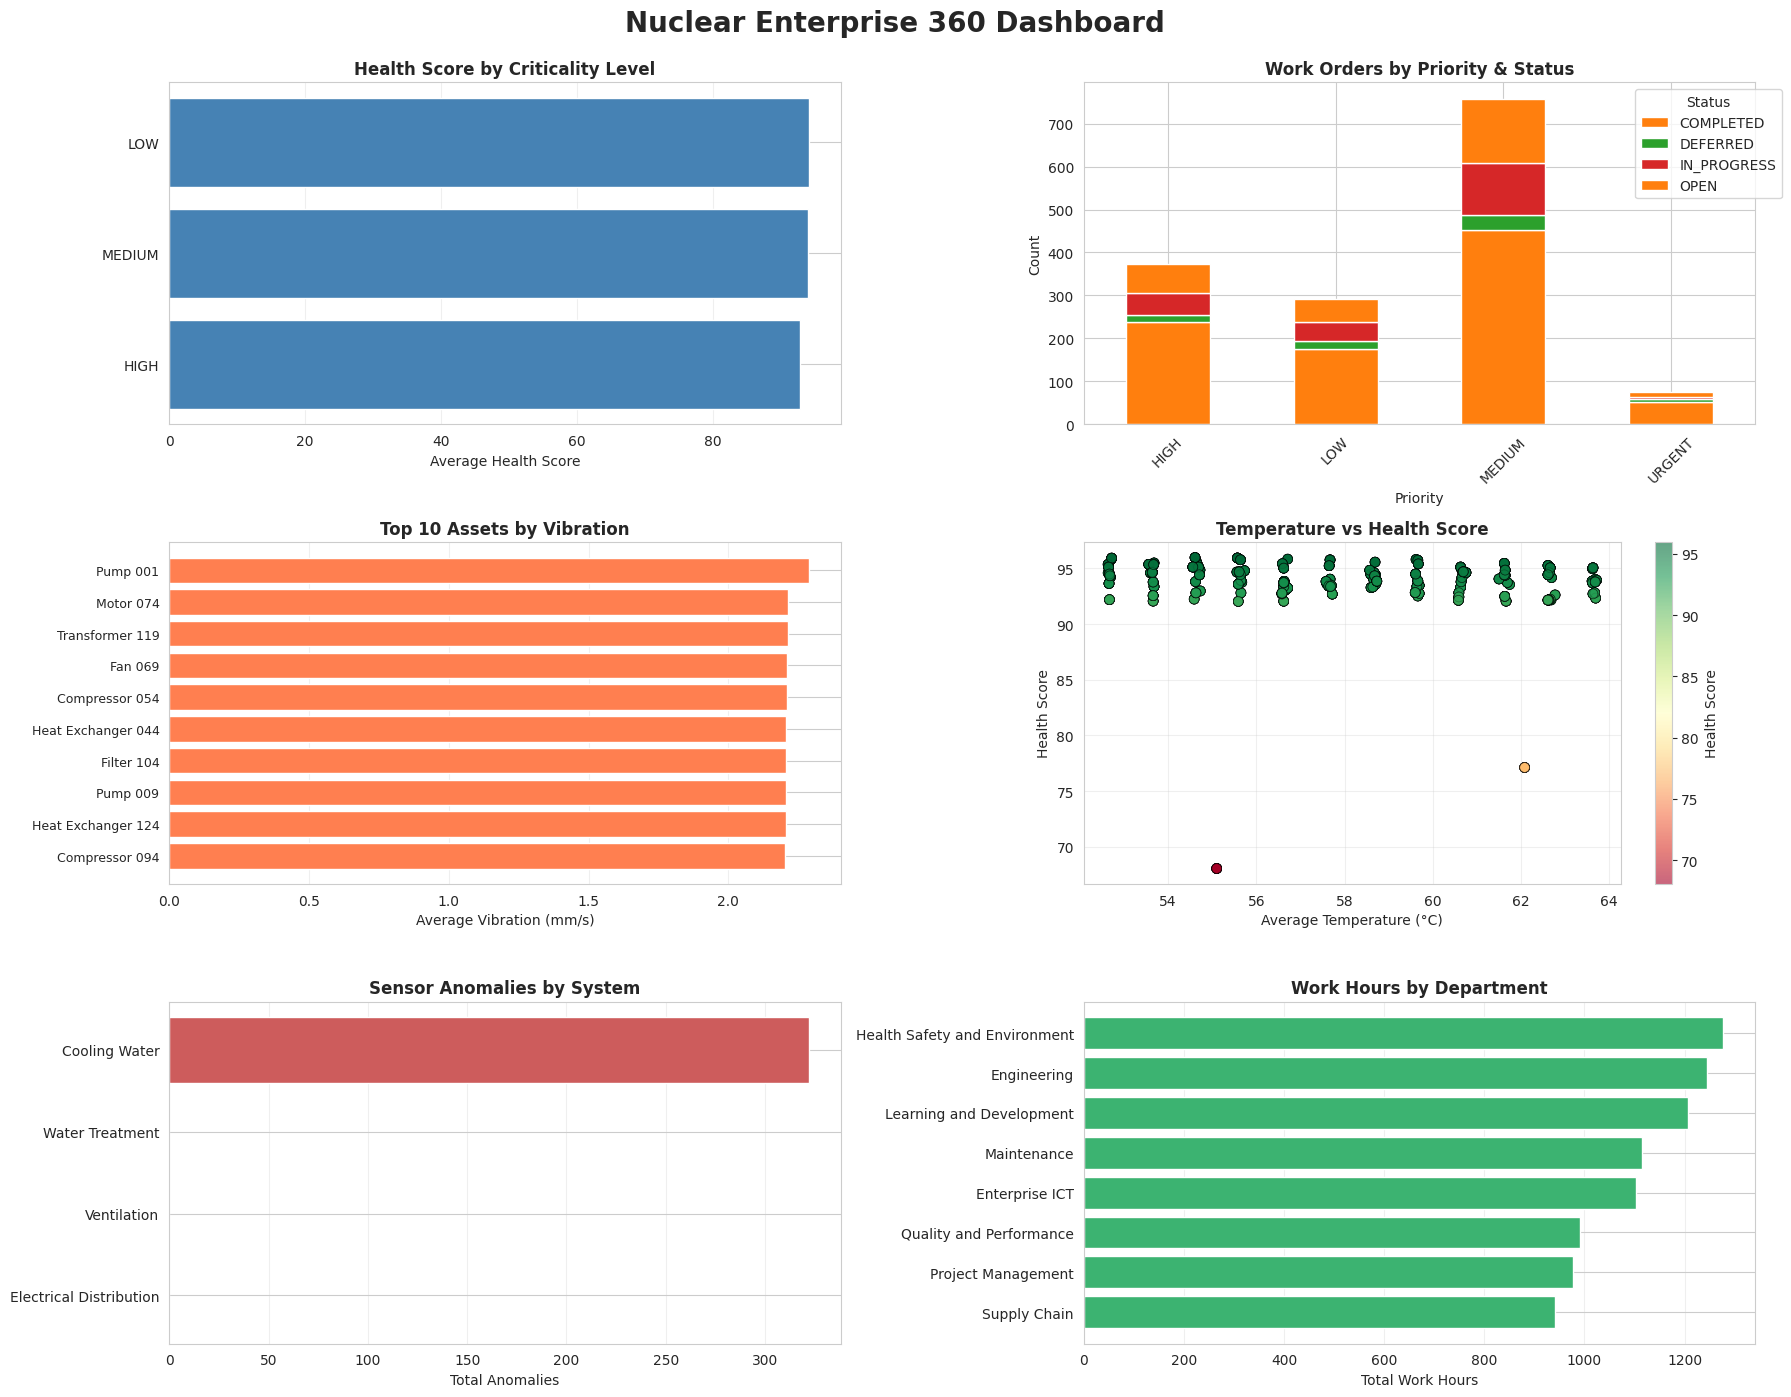

✅ Dashboard visualization complete


In [0]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np

# Set style
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (16, 12)

# Create comprehensive dataset
comprehensive_df = spark.sql("""
    SELECT 
        -- Asset information
        a.asset_id,
        a.asset_name,
        a.asset_type,
        a.system_name,
        a.criticality,
        a.health_score,
        a.risk_level,
        
        -- Work orders
        w.work_order_id,
        w.priority,
        w.status as work_status,
        w.problem_description,
        w.created_date as planned_start_date,
        w.completed_date,
        w.actual_hours,
        w.assigned_employee_id,
        
        -- Sensor readings aggregated
        s.avg_vibration,
        s.avg_temperature,
        s.total_anomalies,
        s.reading_count,
        
        -- Employee info
        e.role_title as employee_name,
        d.department_name as department,
        e.role_title as position
        
    FROM asset_360 a
    LEFT JOIN work_orders w ON a.asset_id = w.asset_id
    LEFT JOIN (
        SELECT 
            asset_id,
            ROUND(AVG(vibration_mm_s), 3) as avg_vibration,
            ROUND(AVG(temperature_c), 2) as avg_temperature,
            SUM(anomaly_flag) as total_anomalies,
            COUNT(*) as reading_count
        FROM sensor_readings
        GROUP BY asset_id
    ) s ON a.asset_id = s.asset_id
    LEFT JOIN employees e ON w.assigned_employee_id = e.employee_id
    LEFT JOIN departments d ON e.department_id = d.department_id
""").toPandas()

print("\n" + "="*80)
print("NUCLEAR ENTERPRISE 360 DASHBOARD")
print("="*80)
print(f"Total Assets: {comprehensive_df['asset_id'].nunique()}")
print(f"Total Work Orders: {comprehensive_df['work_order_id'].nunique()}")
print(f"Average Health Score: {comprehensive_df['health_score'].mean():.2f}")
print(f"Total Anomalies: {comprehensive_df['total_anomalies'].sum():.0f}")
print(f"Open Work Orders: {(comprehensive_df['work_status'] == 'OPEN').sum()}")
print(f"High Priority Items: {(comprehensive_df['priority'] == 'HIGH').sum()}")
print("="*80 + "\n")

# Create 6-panel dashboard
fig, axes = plt.subplots(3, 2, figsize=(18, 14))
fig.suptitle('Nuclear Enterprise 360 Dashboard', fontsize=20, fontweight='bold', y=0.995)

# 1. Average Health Score by Criticality
health_by_crit = comprehensive_df.groupby('criticality')['health_score'].mean().sort_values()
axes[0, 0].barh(health_by_crit.index, health_by_crit.values, color='steelblue')
axes[0, 0].set_xlabel('Average Health Score')
axes[0, 0].set_title('Health Score by Criticality Level', fontweight='bold')
axes[0, 0].grid(axis='x', alpha=0.3)

# 2. Work Order Status by Priority
work_status = comprehensive_df.groupby(['priority', 'work_status']).size().reset_index(name='count')
work_pivot = work_status.pivot(index='priority', columns='work_status', values='count').fillna(0)
work_pivot.plot(kind='bar', stacked=True, ax=axes[0, 1], color=['#ff7f0e', '#2ca02c', '#d62728'])
axes[0, 1].set_title('Work Orders by Priority & Status', fontweight='bold')
axes[0, 1].set_xlabel('Priority')
axes[0, 1].set_ylabel('Count')
axes[0, 1].legend(title='Status', bbox_to_anchor=(1.05, 1))
axes[0, 1].tick_params(axis='x', rotation=45)

# 3. Top 10 Assets by Average Vibration
top_vib = comprehensive_df.groupby('asset_name')['avg_vibration'].mean().nlargest(10).sort_values()
axes[1, 0].barh(range(len(top_vib)), top_vib.values, color='coral')
axes[1, 0].set_yticks(range(len(top_vib)))
axes[1, 0].set_yticklabels(top_vib.index, fontsize=9)
axes[1, 0].set_xlabel('Average Vibration (mm/s)')
axes[1, 0].set_title('Top 10 Assets by Vibration', fontweight='bold')
axes[1, 0].grid(axis='x', alpha=0.3)

# 4. Temperature vs Health Score Scatter
scatter_data = comprehensive_df.dropna(subset=['avg_temperature', 'health_score'])
scatter = axes[1, 1].scatter(scatter_data['avg_temperature'], 
                              scatter_data['health_score'],
                              c=scatter_data['health_score'], 
                              cmap='RdYlGn', 
                              s=50, 
                              alpha=0.6,
                              edgecolors='black',
                              linewidth=0.5)
axes[1, 1].set_xlabel('Average Temperature (°C)')
axes[1, 1].set_ylabel('Health Score')
axes[1, 1].set_title('Temperature vs Health Score', fontweight='bold')
axes[1, 1].grid(alpha=0.3)
plt.colorbar(scatter, ax=axes[1, 1], label='Health Score')

# 5. Total Anomalies by System
anomalies = comprehensive_df.groupby('system_name')['total_anomalies'].sum().sort_values()
axes[2, 0].barh(anomalies.index, anomalies.values, color='indianred')
axes[2, 0].set_xlabel('Total Anomalies')
axes[2, 0].set_title('Sensor Anomalies by System', fontweight='bold')
axes[2, 0].grid(axis='x', alpha=0.3)

# 6. Work Hours by Department
dept_hours = comprehensive_df.groupby('department')['actual_hours'].sum().dropna().sort_values()
axes[2, 1].barh(dept_hours.index, dept_hours.values, color='mediumseagreen')
axes[2, 1].set_xlabel('Total Work Hours')
axes[2, 1].set_title('Work Hours by Department', fontweight='bold')
axes[2, 1].grid(axis='x', alpha=0.3)

plt.tight_layout()
plt.show()

print("✅ Dashboard visualization complete")

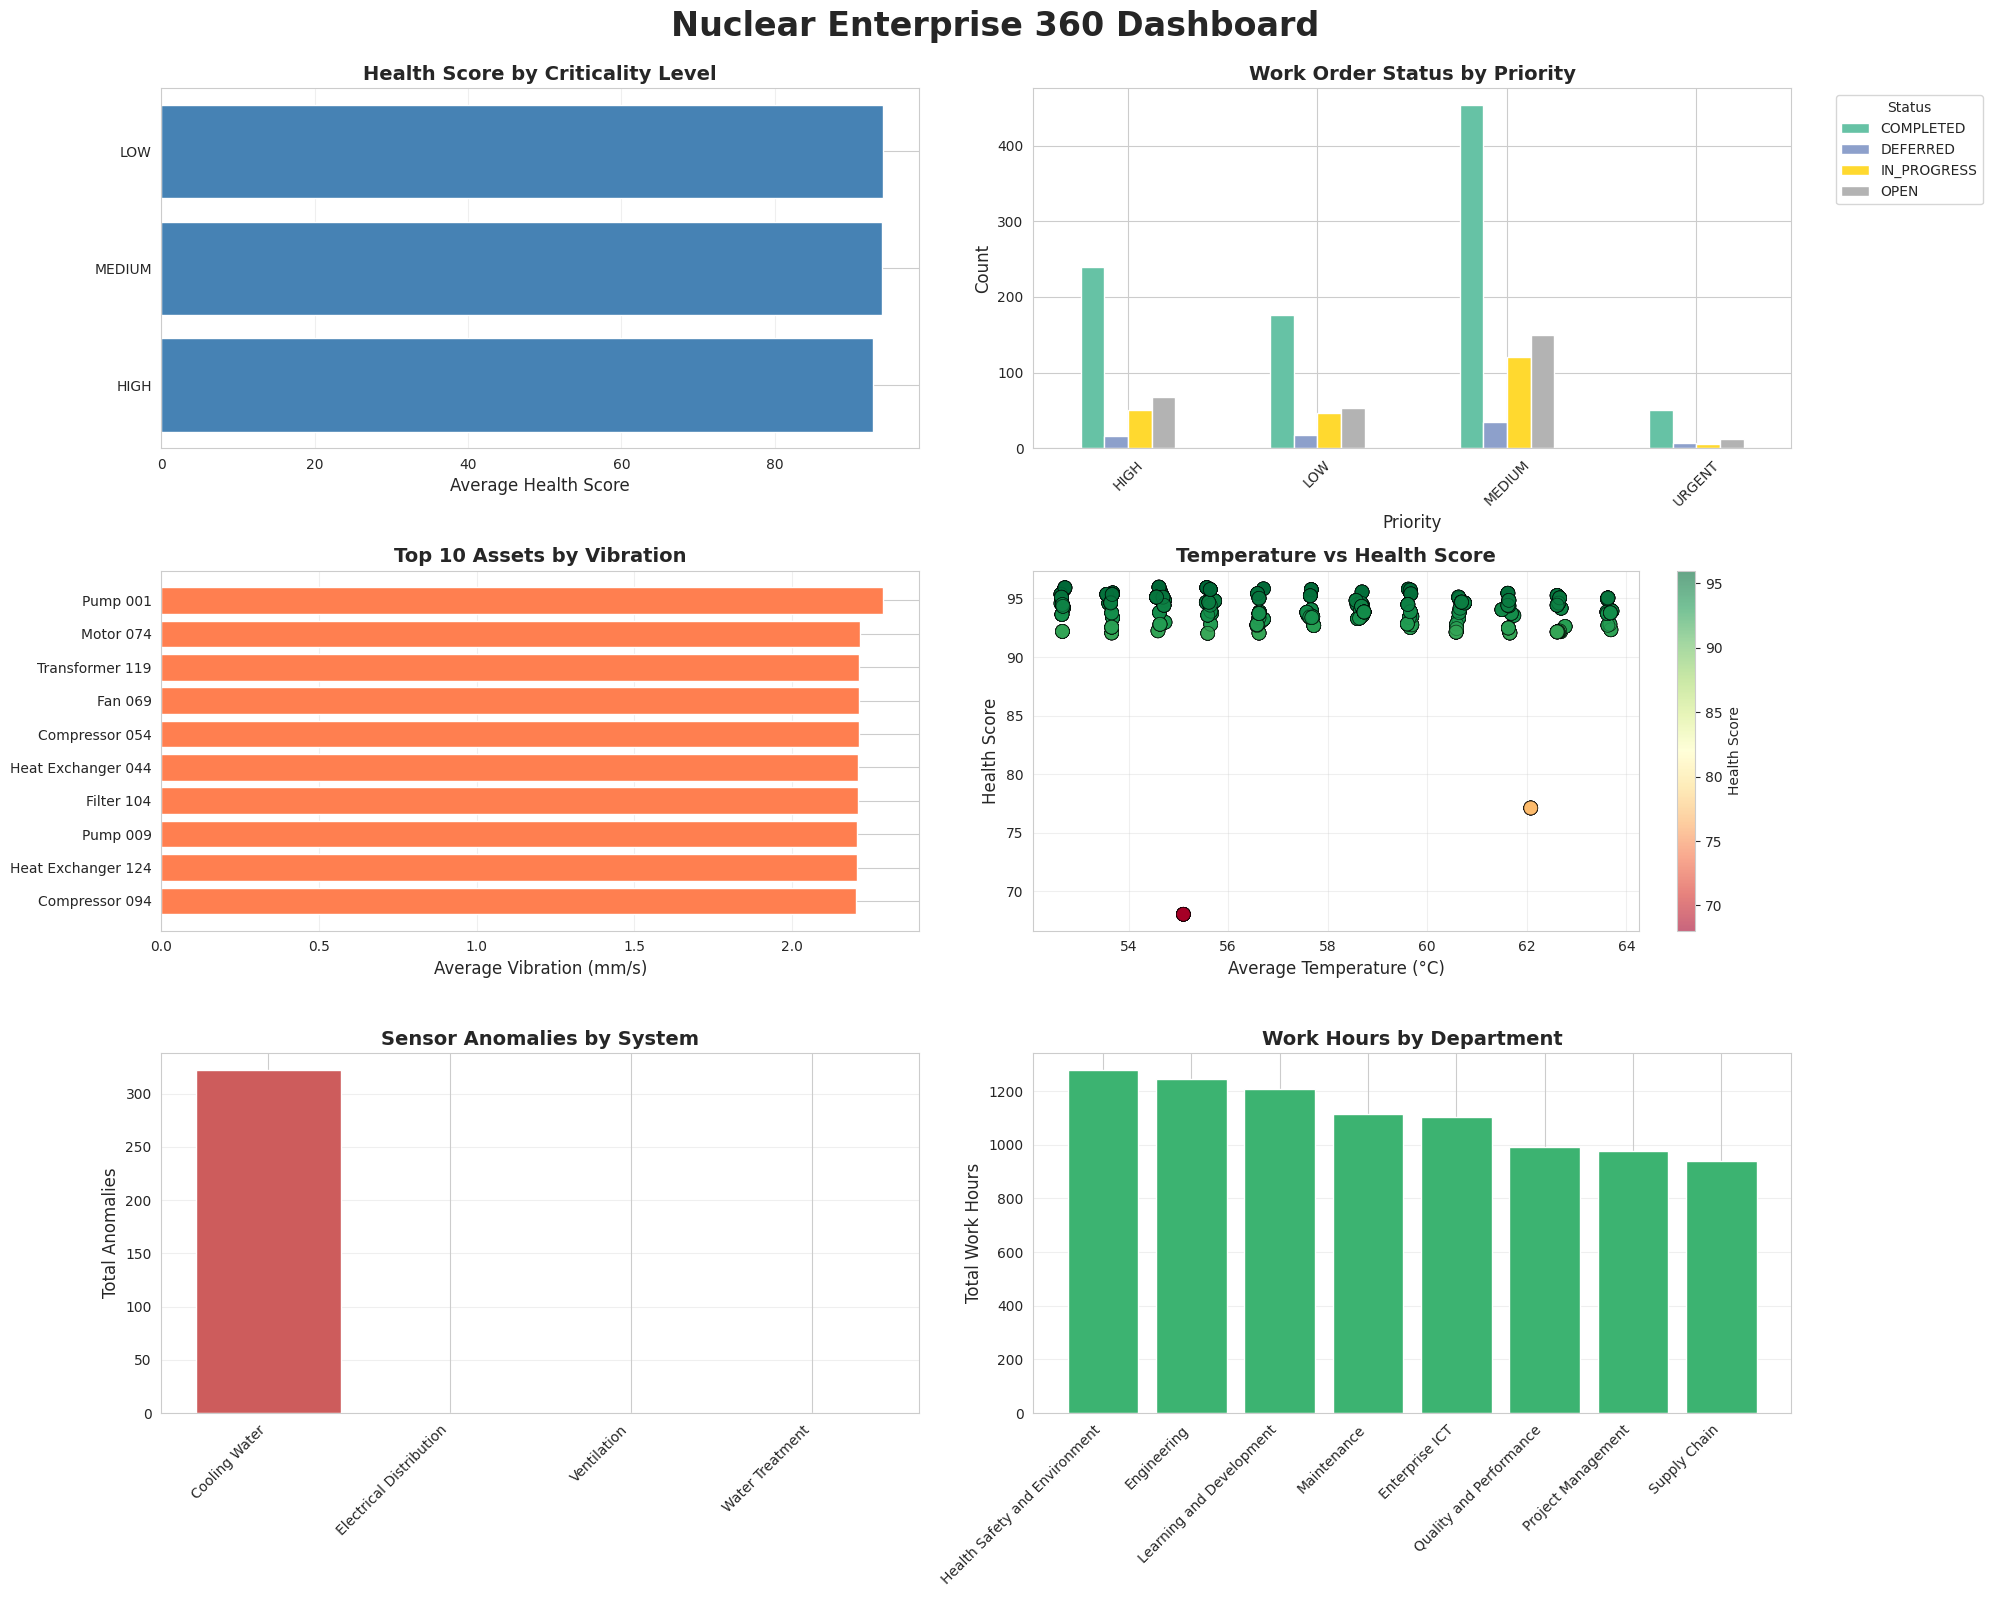


DASHBOARD SUMMARY STATISTICS
Total Assets: 128
Total Work Orders: 1500
Average Health Score: 93.67
Total Anomalies: 322
Open Work Orders: 283
High Priority Items: 374
Critical Assets: 437
High Risk Assets: 0


In [0]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
from pyspark.sql import functions as F

# Set style
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (20, 16)

# Create comprehensive dataset with all relevant joins
comprehensive_df = spark.sql("""
    SELECT 
        -- Asset information
        a.asset_id,
        a.asset_name,
        a.asset_type,
        a.system_name,
        a.criticality,
        a.health_score,
        a.risk_level,
        
        -- Work orders
        w.work_order_id,
        w.priority,
        w.status as work_status,
        w.problem_description,
        w.created_date as planned_start_date,
        w.completed_date,
        w.actual_hours,
        w.assigned_employee_id,
        
        -- Sensor readings aggregated
        s.avg_vibration,
        s.avg_temperature,
        s.total_anomalies,
        s.reading_count,
        
        -- Employee info
        e.role_title as employee_name,
        d.department_name as department,
        e.role_title as position
        
    FROM asset_360 a
    LEFT JOIN work_orders w ON a.asset_id = w.asset_id
    LEFT JOIN (
        SELECT 
            asset_id,
            ROUND(AVG(vibration_mm_s), 3) as avg_vibration,
            ROUND(AVG(temperature_c), 2) as avg_temperature,
            SUM(anomaly_flag) as total_anomalies,
            COUNT(*) as reading_count
        FROM sensor_readings
        GROUP BY asset_id
    ) s ON a.asset_id = s.asset_id
    LEFT JOIN employees e ON w.assigned_employee_id = e.employee_id
    LEFT JOIN departments d ON e.department_id = d.department_id
""").toPandas()

# Create 6-panel dashboard
fig, axes = plt.subplots(3, 2, figsize=(20, 16))
fig.suptitle('Nuclear Enterprise 360 Dashboard', fontsize=24, fontweight='bold', y=0.995)

# 1. Health Score by Criticality
health_by_crit = comprehensive_df.groupby('criticality')['health_score'].mean().sort_values()
axes[0, 0].barh(health_by_crit.index, health_by_crit.values, color='steelblue')
axes[0, 0].set_xlabel('Average Health Score', fontsize=12)
axes[0, 0].set_title('Health Score by Criticality Level', fontsize=14, fontweight='bold')
axes[0, 0].grid(axis='x', alpha=0.3)

# 2. Work Order Status by Priority
work_pivot = comprehensive_df.groupby(['priority', 'work_status']).size().unstack(fill_value=0)
work_pivot.plot(kind='bar', ax=axes[0, 1], stacked=False, colormap='Set2')
axes[0, 1].set_xlabel('Priority', fontsize=12)
axes[0, 1].set_ylabel('Count', fontsize=12)
axes[0, 1].set_title('Work Order Status by Priority', fontsize=14, fontweight='bold')
axes[0, 1].legend(title='Status', bbox_to_anchor=(1.05, 1), loc='upper left')
axes[0, 1].tick_params(axis='x', rotation=45)

# 3. Top 10 Assets by Vibration
vib_data = comprehensive_df.groupby('asset_name')['avg_vibration'].mean().nlargest(10).sort_values()
axes[1, 0].barh(vib_data.index, vib_data.values, color='coral')
axes[1, 0].set_xlabel('Average Vibration (mm/s)', fontsize=12)
axes[1, 0].set_title('Top 10 Assets by Vibration', fontsize=14, fontweight='bold')
axes[1, 0].grid(axis='x', alpha=0.3)

# 4. Temperature vs Health Score Scatter
scatter_data = comprehensive_df.dropna(subset=['avg_temperature', 'health_score'])
scatter = axes[1, 1].scatter(scatter_data['avg_temperature'], 
                             scatter_data['health_score'],
                             c=scatter_data['health_score'], 
                             cmap='RdYlGn', 
                             s=100, 
                             alpha=0.6,
                             edgecolors='black',
                             linewidth=0.5)
axes[1, 1].set_xlabel('Average Temperature (°C)', fontsize=12)
axes[1, 1].set_ylabel('Health Score', fontsize=12)
axes[1, 1].set_title('Temperature vs Health Score', fontsize=14, fontweight='bold')
axes[1, 1].grid(alpha=0.3)
plt.colorbar(scatter, ax=axes[1, 1], label='Health Score')

# 5. Anomalies by System
anomaly_data = comprehensive_df.groupby('system_name')['total_anomalies'].sum().sort_values(ascending=False)
axes[2, 0].bar(range(len(anomaly_data)), anomaly_data.values, color='indianred')
axes[2, 0].set_xticks(range(len(anomaly_data)))
axes[2, 0].set_xticklabels(anomaly_data.index, rotation=45, ha='right')
axes[2, 0].set_ylabel('Total Anomalies', fontsize=12)
axes[2, 0].set_title('Sensor Anomalies by System', fontsize=14, fontweight='bold')
axes[2, 0].grid(axis='y', alpha=0.3)

# 6. Work Hours by Department
dept_hours = comprehensive_df.groupby('department')['actual_hours'].sum().sort_values(ascending=False)
axes[2, 1].bar(range(len(dept_hours)), dept_hours.values, color='mediumseagreen')
axes[2, 1].set_xticks(range(len(dept_hours)))
axes[2, 1].set_xticklabels(dept_hours.index, rotation=45, ha='right')
axes[2, 1].set_ylabel('Total Work Hours', fontsize=12)
axes[2, 1].set_title('Work Hours by Department', fontsize=14, fontweight='bold')
axes[2, 1].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

# Print summary statistics
print("\n" + "="*80)
print("DASHBOARD SUMMARY STATISTICS")
print("="*80)
print(f"Total Assets: {comprehensive_df['asset_id'].nunique()}")
print(f"Total Work Orders: {comprehensive_df['work_order_id'].nunique()}")
print(f"Average Health Score: {comprehensive_df['health_score'].mean():.2f}")
print(f"Total Anomalies: {comprehensive_df['total_anomalies'].sum():.0f}")
print(f"Open Work Orders: {(comprehensive_df['work_status'] == 'OPEN').sum()}")
print(f"High Priority Items: {(comprehensive_df['priority'] == 'HIGH').sum()}")
print(f"Critical Assets: {(comprehensive_df['criticality'] == 'HIGH').sum()}")
print(f"High Risk Assets: {(comprehensive_df['risk_level'] == 'HIGH').sum()}")
print("="*80)

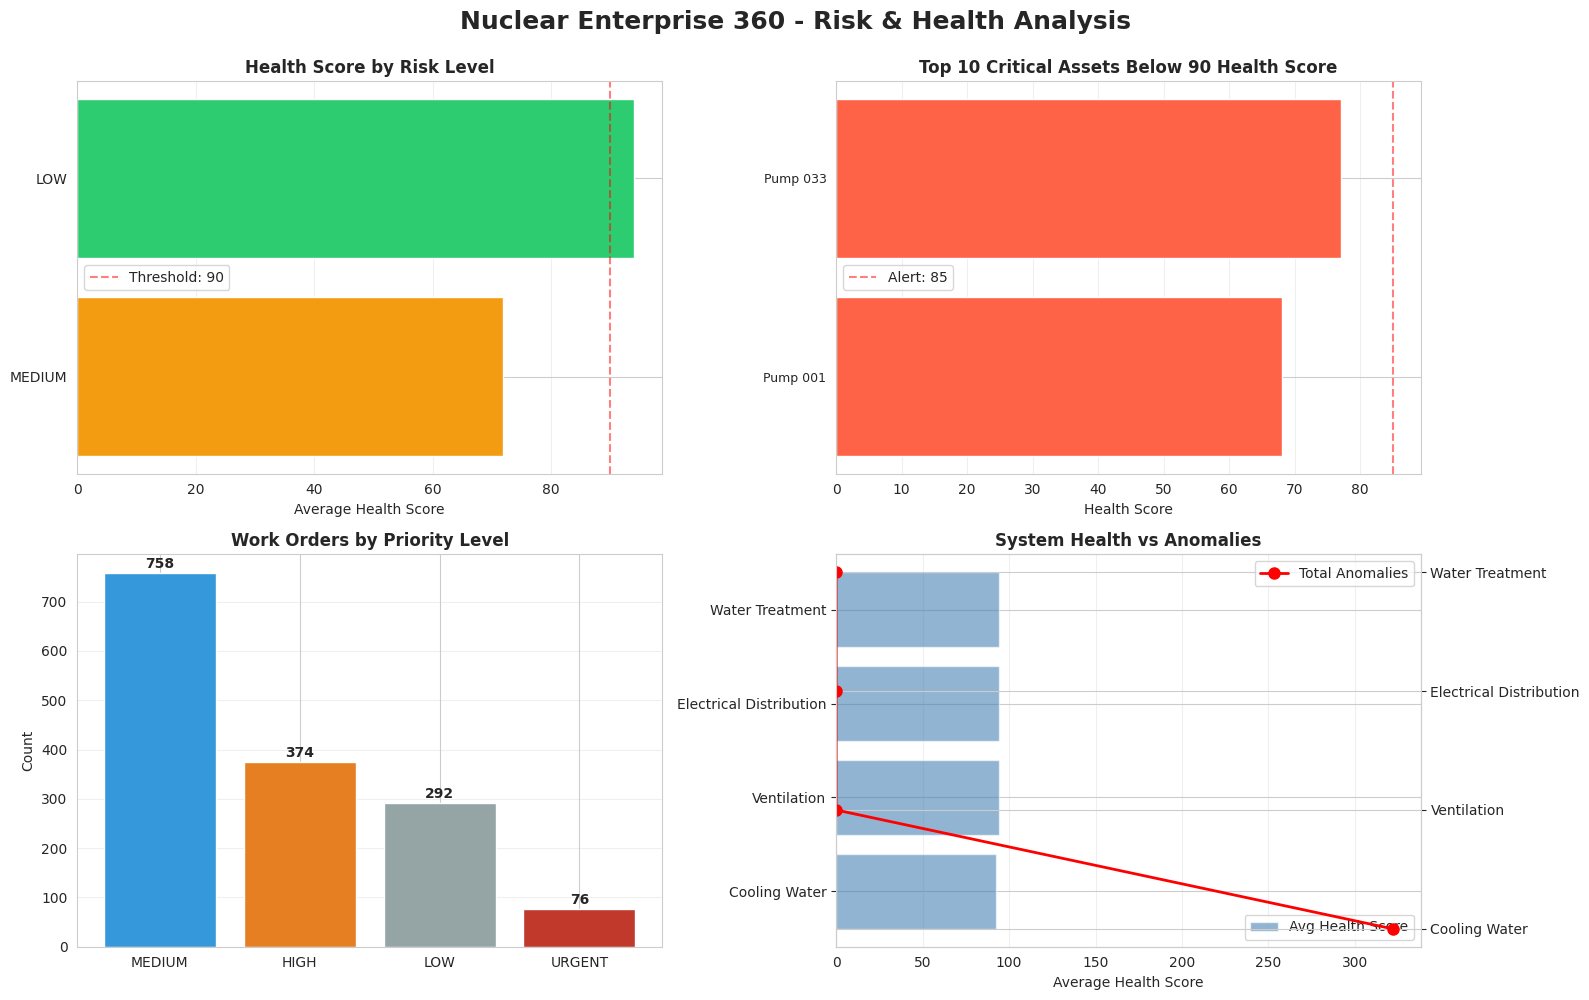


📊 Additional analysis visualizations complete


In [0]:
# Additional focused visualizations
import matplotlib.pyplot as plt
import seaborn as sns

fig, axes = plt.subplots(2, 2, figsize=(16, 10))
fig.suptitle('Nuclear Enterprise 360 - Risk & Health Analysis', fontsize=18, fontweight='bold', y=0.995)

# 1. Health Score Distribution by Risk Level
risk_health = comprehensive_df.groupby('risk_level')['health_score'].mean().sort_values()
colors = {'LOW': '#2ecc71', 'MEDIUM': '#f39c12', 'HIGH': '#e74c3c'}
bar_colors = [colors.get(x, 'gray') for x in risk_health.index]
axes[0, 0].barh(risk_health.index, risk_health.values, color=bar_colors)
axes[0, 0].set_xlabel('Average Health Score')
axes[0, 0].set_title('Health Score by Risk Level', fontweight='bold')
axes[0, 0].axvline(x=90, color='red', linestyle='--', alpha=0.5, label='Threshold: 90')
axes[0, 0].legend()
axes[0, 0].grid(axis='x', alpha=0.3)

# 2. Critical Assets Requiring Attention
critical_assets = comprehensive_df[
    (comprehensive_df['criticality'] == 'HIGH') & 
    (comprehensive_df['health_score'] < 90)
].groupby('asset_name')['health_score'].first().sort_values().head(10)

if len(critical_assets) > 0:
    axes[0, 1].barh(range(len(critical_assets)), critical_assets.values, color='tomato')
    axes[0, 1].set_yticks(range(len(critical_assets)))
    axes[0, 1].set_yticklabels(critical_assets.index, fontsize=9)
    axes[0, 1].set_xlabel('Health Score')
    axes[0, 1].set_title('Top 10 Critical Assets Below 90 Health Score', fontweight='bold')
    axes[0, 1].axvline(x=85, color='red', linestyle='--', alpha=0.5, label='Alert: 85')
    axes[0, 1].legend()
    axes[0, 1].grid(axis='x', alpha=0.3)
else:
    axes[0, 1].text(0.5, 0.5, 'No critical assets below threshold', 
                     ha='center', va='center', fontsize=12)
    axes[0, 1].set_title('Top 10 Critical Assets Below 90 Health Score', fontweight='bold')

# 3. Work Order Priority Distribution
priority_counts = comprehensive_df['priority'].value_counts()
colors_priority = {'LOW': '#95a5a6', 'MEDIUM': '#3498db', 'HIGH': '#e67e22', 'URGENT': '#c0392b'}
bar_colors_priority = [colors_priority.get(x, 'gray') for x in priority_counts.index]
axes[1, 0].bar(priority_counts.index, priority_counts.values, color=bar_colors_priority)
axes[1, 0].set_ylabel('Count')
axes[1, 0].set_title('Work Orders by Priority Level', fontweight='bold')
axes[1, 0].grid(axis='y', alpha=0.3)
for i, v in enumerate(priority_counts.values):
    axes[1, 0].text(i, v + 10, str(v), ha='center', fontweight='bold')

# 4. System Health Overview
system_health = comprehensive_df.groupby('system_name').agg({
    'health_score': 'mean',
    'total_anomalies': 'sum'
}).sort_values('health_score')

ax2 = axes[1, 1].twinx()
axes[1, 1].barh(system_health.index, system_health['health_score'], alpha=0.6, color='steelblue', label='Avg Health Score')
ax2.plot(system_health['total_anomalies'], system_health.index, 'ro-', linewidth=2, markersize=8, label='Total Anomalies')
axes[1, 1].set_xlabel('Average Health Score')
axes[1, 1].set_title('System Health vs Anomalies', fontweight='bold')
ax2.set_xlabel('Total Anomalies')
axes[1, 1].legend(loc='lower right')
ax2.legend(loc='upper right')
axes[1, 1].grid(axis='x', alpha=0.3)

plt.tight_layout()
plt.show()

print("\n📊 Additional analysis visualizations complete")

In [0]:
# ============================================================
# DYNAMIC Asset Dashboard — change the dropdown and charts update
# ============================================================
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import ipywidgets as widgets
from IPython.display import display

# Fetch all asset names dynamically from the table
asset_names = [row.asset_name for row in spark.sql(
    "SELECT DISTINCT asset_name FROM asset_360 ORDER BY asset_name"
).collect()]

# Create the dropdown (appears inline in cell output)
asset_dropdown = widgets.Dropdown(
    options=asset_names,
    value='Motor 002',
    description='Select Asset:',
    style={'description_width': 'initial'},
    layout={'width': '500px'}
)

def render_dashboard(selected_asset):
    """Fetch data for the selected asset and render the 4-panel dashboard."""
    asset_df = spark.sql(f"""
        SELECT 
            a.asset_id, a.asset_name, a.asset_type, a.system_name,
            a.criticality, a.health_score, a.risk_level,
            w.work_order_id, w.priority, w.status as work_status,
            w.problem_description, w.created_date, w.completed_date,
            w.actual_hours,
            e.role_title as employee_name,
            d.department_name as department,
            s.reading_timestamp, s.vibration_mm_s, s.temperature_c,
            s.anomaly_flag, s.sensor_quality
        FROM asset_360 a
        LEFT JOIN work_orders w ON a.asset_id = w.asset_id
        LEFT JOIN employees e ON w.assigned_employee_id = e.employee_id
        LEFT JOIN departments d ON e.department_id = d.department_id
        LEFT JOIN sensor_readings s ON a.asset_id = s.asset_id
        WHERE a.asset_name = '{selected_asset}'
    """).toPandas()

    print("\n" + "=" * 80)
    print(f"ASSET DASHBOARD: {selected_asset}")
    print("=" * 80)

    if asset_df.empty:
        print(f"No data found for asset: {selected_asset}")
        return

    row = asset_df.iloc[0]
    print(f"Asset ID:       {row['asset_id']}")
    print(f"Asset Type:     {row['asset_type']}")
    print(f"System:         {row['system_name']}")
    print(f"Criticality:    {row['criticality']}")
    print(f"Health Score:   {row['health_score']}")
    print(f"Risk Level:     {row['risk_level']}")
    print(f"Work Orders:    {asset_df['work_order_id'].nunique()}")
    print(f"Sensor Readings:{asset_df['reading_timestamp'].count()}")
    print(f"Anomalies:      {asset_df['anomaly_flag'].sum():.0f}")
    print("=" * 80 + "\n")

    fig, axes = plt.subplots(2, 2, figsize=(16, 10))
    fig.suptitle(f'Asset Dashboard: {selected_asset}', fontsize=18, fontweight='bold', y=0.995)

    # 1. Sensor trends over time
    if asset_df['reading_timestamp'].notna().any():
        ts_df = asset_df.dropna(subset=['reading_timestamp']).sort_values('reading_timestamp')
        if len(ts_df) > 0:
            ax1 = axes[0, 0]
            ax1b = ax1.twinx()
            ax1.plot(ts_df['reading_timestamp'], ts_df['vibration_mm_s'], 'b-', alpha=0.7, label='Vibration (mm/s)')
            ax1b.plot(ts_df['reading_timestamp'], ts_df['temperature_c'], 'r-', alpha=0.7, label='Temperature (C)')
            ax1.set_xlabel('Timestamp')
            ax1.set_ylabel('Vibration (mm/s)', color='blue')
            ax1b.set_ylabel('Temperature (C)', color='red')
            ax1.set_title('Sensor Trends Over Time', fontweight='bold')
            ax1.tick_params(axis='x', rotation=45)
            ax1.grid(alpha=0.3)
            ax1.legend(loc='upper left')
            ax1b.legend(loc='upper right')
    else:
        axes[0, 0].text(0.5, 0.5, 'No sensor data available', ha='center', va='center')
        axes[0, 0].set_title('Sensor Trends Over Time', fontweight='bold')

    # 2. Work order status
    work_orders = asset_df.dropna(subset=['work_order_id']).drop_duplicates(subset=['work_order_id'])
    if len(work_orders) > 0:
        status_counts = work_orders['work_status'].value_counts()
        colors_status = {'OPEN': '#e74c3c', 'IN_PROGRESS': '#f39c12', 'COMPLETED': '#2ecc71', 'CANCELLED': '#95a5a6'}
        bar_colors = [colors_status.get(x, 'gray') for x in status_counts.index]
        axes[0, 1].bar(status_counts.index, status_counts.values, color=bar_colors)
        axes[0, 1].set_ylabel('Count')
        axes[0, 1].set_title('Work Order Status', fontweight='bold')
        axes[0, 1].grid(axis='y', alpha=0.3)
        for i, v in enumerate(status_counts.values):
            axes[0, 1].text(i, v + 0.1, str(v), ha='center', fontweight='bold')
    else:
        axes[0, 1].text(0.5, 0.5, 'No work orders', ha='center', va='center')
        axes[0, 1].set_title('Work Order Status', fontweight='bold')

    # 3. Health score gauge
    health = row['health_score']
    axes[1, 0].barh(['Health Score'], [health],
                     color='#2ecc71' if health >= 90 else ('#f39c12' if health >= 75 else '#e74c3c'))
    axes[1, 0].set_xlim(0, 100)
    axes[1, 0].axvline(x=90, color='green', linestyle='--', alpha=0.5, label='Good (90)')
    axes[1, 0].axvline(x=75, color='orange', linestyle='--', alpha=0.5, label='Warning (75)')
    axes[1, 0].set_title('Health Score', fontweight='bold')
    axes[1, 0].legend(fontsize=8)
    axes[1, 0].grid(axis='x', alpha=0.3)

    # 4. Anomaly distribution
    if asset_df['anomaly_flag'].sum() > 0:
        anomaly_by_quality = asset_df.groupby('sensor_quality')['anomaly_flag'].sum()
        axes[1, 1].bar(anomaly_by_quality.index, anomaly_by_quality.values, color=['#2ecc71', '#e74c3c', '#f39c12'])
        axes[1, 1].set_ylabel('Anomaly Count')
        axes[1, 1].set_title('Anomalies by Sensor Quality', fontweight='bold')
        axes[1, 1].grid(axis='y', alpha=0.3)
    else:
        axes[1, 1].text(0.5, 0.5, 'No anomalies detected', ha='center', va='center', fontsize=12)
        axes[1, 1].set_title('Anomalies by Sensor Quality', fontweight='bold')

    plt.tight_layout()
    plt.show()

# Link dropdown to render function — output auto-updates when dropdown changes
dashboard_output = widgets.interactive_output(render_dashboard, {'selected_asset': asset_dropdown})

# Display dropdown on top, dynamic dashboard output below
display(widgets.VBox([asset_dropdown, dashboard_output]))

## 5. Delta Lake lab — preserve history

Work on a laboratory copy, not the original table.

In [0]:
spark.sql("DROP TABLE IF EXISTS work_orders_lab")
spark.sql("CREATE TABLE work_orders_lab AS SELECT * FROM work_orders")
print("Created work_orders_lab")

In [0]:
%sql
UPDATE work_orders_lab
SET status = 'IN_PROGRESS'
WHERE work_order_id = 'WO-00001';

In [0]:
%sql
DESCRIBE HISTORY work_orders_lab;

Replace `VERSION AS OF 0` below if your history shows a different first version.

In [0]:
%sql
SELECT work_order_id, status
FROM work_orders_lab VERSION AS OF 0
WHERE work_order_id = 'WO-00001';

## 6. Team mission

Prepare a five-line evidence briefing for one of these missions:

1. **Asset Health:** Which asset requires the most urgent human review, and why?
2. **Project Risk:** Which project has the most urgent governance gap?
3. **Workforce Readiness:** Which work assignments have qualification concerns?
4. **Evidence Quality:** Which “completed” records should not be trusted yet?

Your briefing must include:
- the SQL query;
- the result rows;
- what the data supports;
- what the data does **not** prove;
- the next human decision.

In [0]:
# ============================================================
# TIME SERIES FORECASTING OPTIONS
# ============================================================

# Based on your Nuclear Enterprise 360 data, here are several forecasting opportunities:

# 1. SENSOR TEMPERATURE FORECASTING
#    - Predict future temperature trends by asset or system
#    - Early warning for thermal anomalies

# 2. WORK ORDER VOLUME FORECASTING
#    - Predict maintenance workload by priority level
#    - Resource planning for departments

# 3. ASSET HEALTH SCORE FORECASTING
#    - Predict health score degradation
#    - Proactive maintenance scheduling

# 4. ANOMALY RATE FORECASTING
#    - Predict future sensor anomaly rates by system
#    - Risk assessment and prevention

print("\n" + "="*80)
print("FORECASTING OPPORTUNITIES IN YOUR NUCLEAR ENTERPRISE DATA")
print("="*80)
print("\n1. Sensor Temperature Forecasting")
print("   → Predict temperature trends by asset/system")
print("   → Uses: sensor_readings table with temperature_c over time")
print("\n2. Work Order Volume Forecasting")
print("   → Predict future maintenance workload")
print("   → Uses: work_orders table with created_date")
print("\n3. Asset Health Score Trends")
print("   → Predict health score degradation")
print("   → Requires: time-series of health_score snapshots")
print("\n4. Anomaly Rate Forecasting")
print("   → Predict sensor anomaly rates by system")
print("   → Uses: sensor_readings with anomaly_flag over time")
print("\n" + "="*80)
print("\nRECOMMENDATION: Start with option 1 or 4 - you have rich sensor data!")
print("="*80)


FORECASTING OPPORTUNITIES IN YOUR NUCLEAR ENTERPRISE DATA

1. Sensor Temperature Forecasting
   → Predict temperature trends by asset/system
   → Uses: sensor_readings table with temperature_c over time

2. Work Order Volume Forecasting
   → Predict future maintenance workload
   → Uses: work_orders table with created_date

3. Asset Health Score Trends
   → Predict health score degradation
   → Requires: time-series of health_score snapshots

4. Anomaly Rate Forecasting
   → Predict sensor anomaly rates by system
   → Uses: sensor_readings with anomaly_flag over time


RECOMMENDATION: Start with option 1 or 4 - you have rich sensor data!


Looking in indexes: [REDACTED]
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.9/11.9 MB 119.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 88.6 MB/s eta 0:00:00
Note: you may need to restart the kernel using %restart_python or dbutils.library.restartPython() to use updated packages.

SENSOR TEMPERATURE FORECASTING ANALYSIS

[1/4] Loading and preparing sensor temperature data...
Total sensor readings: 44,229
Unique assets: 128
Date range: 2026-05-28T00:00:00 to 2026-08-25T18:00:00
Average temperature: 58.10°C

[2/4] Selecting asset with most readings for forecast...
Selected asset: Compressor 062 (ID: A-062)
Number of readings: 354

[3/4] Training Prophet model for Compressor 062...


2026/08/26 15:14:08 INFO mlflow.tracking.fluent: Experiment with name '/Users/marshadahmad83@gmail.com/sensor-temperature-forecasting' does not exist. Creating a new experiment.
15:14:09 - cmdstanpy - INFO - Chain [1] start processing
15:14:09 - cmdstanpy - INFO - Chain [1] done processing
/local_disk0/.ephemeral_nfs/envs/pythonEnv-57208cfe-60a6-44d0-806a-e7b3c2115591/lib/python3.12/site-packages/prophet/forecaster.py:2206: FutureWarning:

'H' is deprecated and will be removed in a future version, please use 'h' instead.

2026/08/26 15:14:10 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
🔗 View Logged Model at: https://dbc-45ef533b-b71f.cloud.databricks.com/ml/experiments/1208345179772630/models/m-dea6f02670fe4bada3f85b4b9ff79ed3?o=7474647605328427
2026/08/26 15:14:12 INFO mlflow.models.model: Model logged without a signature. Signatures are required for Databricks UC model registry as they validate model inputs and denote the expected schema of 

Model trained successfully!
  MAE: 0.73°C
  RMSE: 0.85°C
  MAPE: 1.33%
  MLflow Run ID: 8354f66c63ff43ab82b1a5b0b37c5a90

[4/4] Generating forecast visualizations...


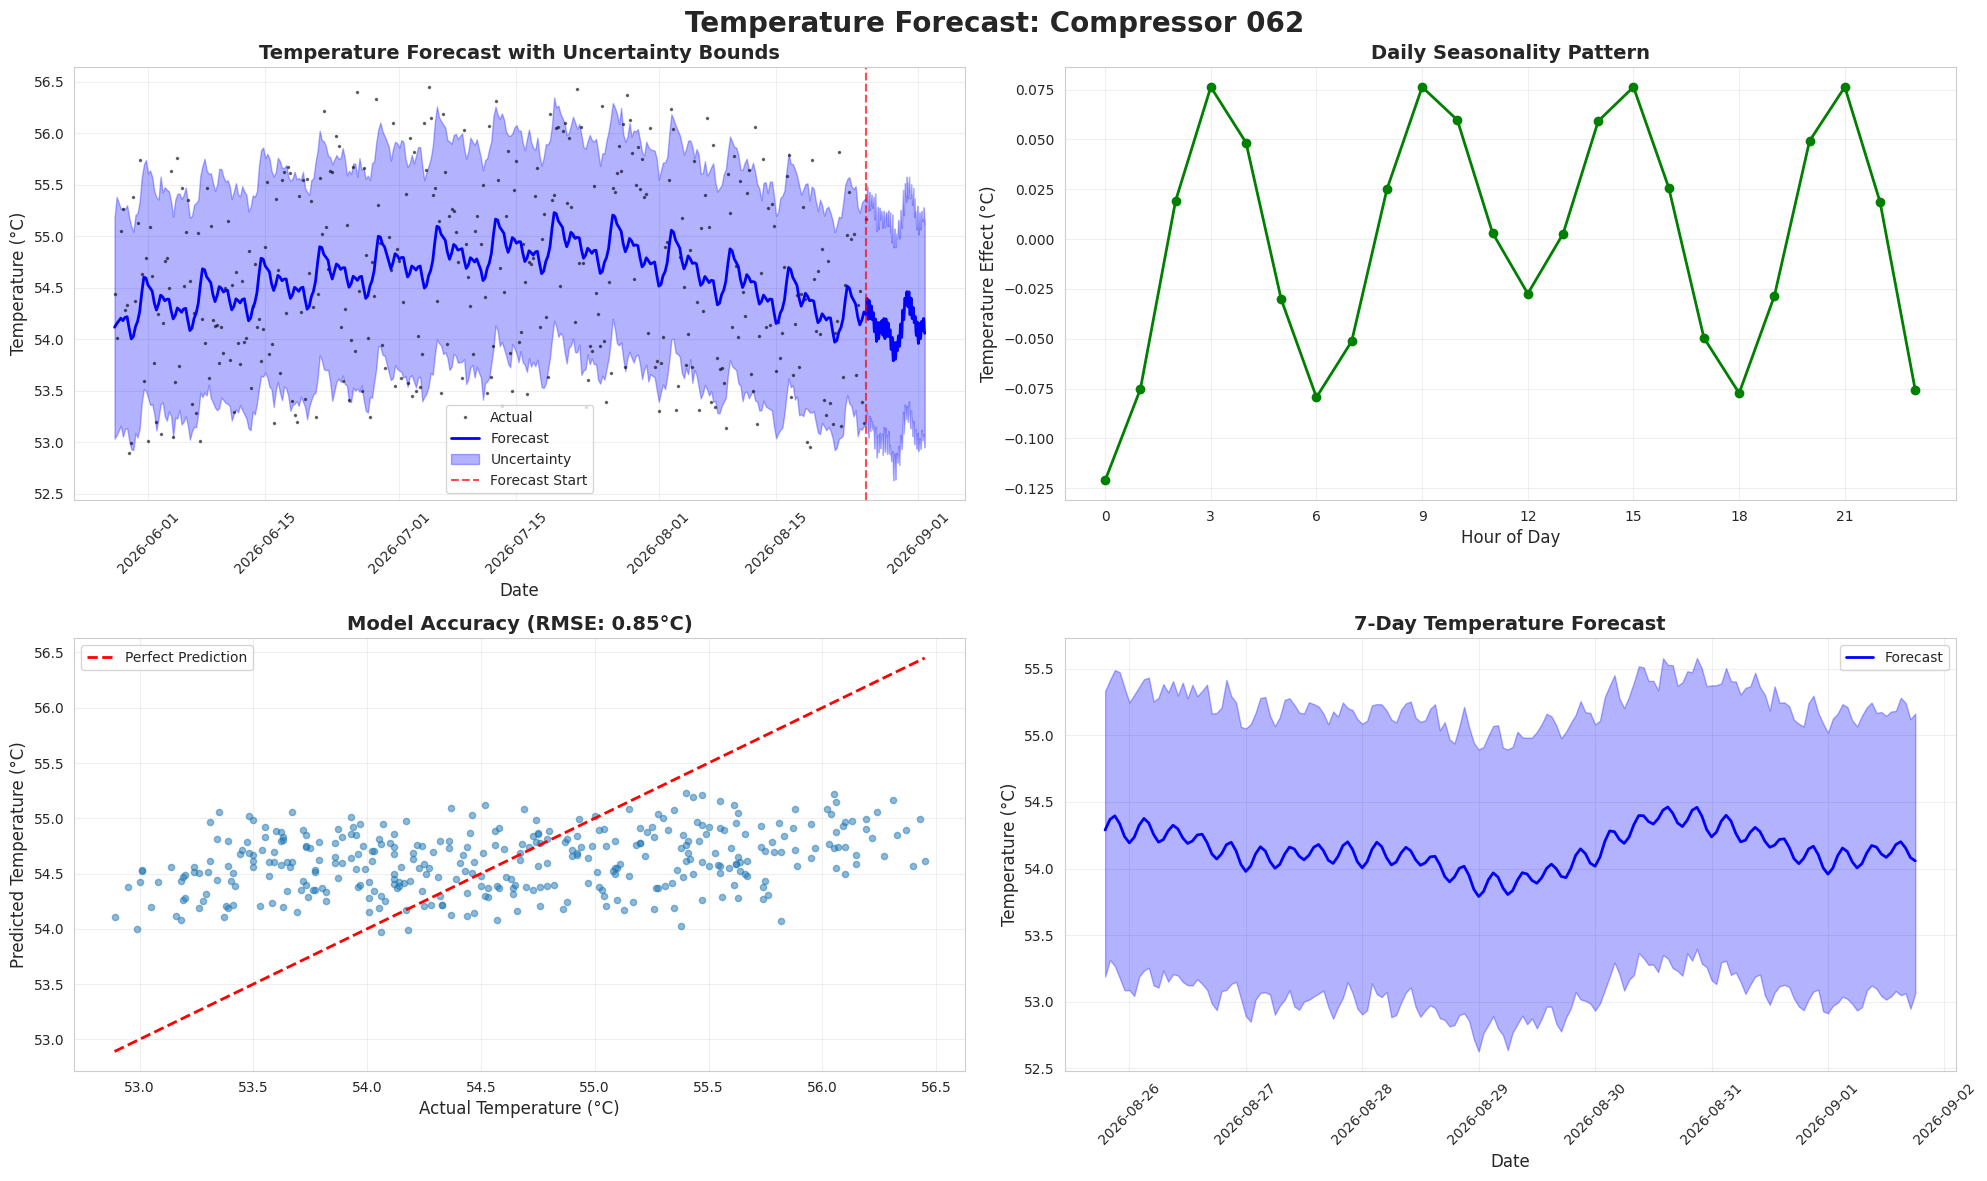


FORECAST SUMMARY

📊 Compressor 062 - 7 Day Forecast:
   Expected Average: 54.14°C
   Expected Range: 53.79°C - 54.46°C
   Predicted Peak: 54.46°C on 2026-08-30 15:00:00
   Predicted Low: 53.79°C on 2026-08-29 00:00:00

✅ Forecast within normal operating range
   Historical mean: 54.61°C
   Forecast stays within ±2σ bounds

✅ Forecasting analysis complete!


In [0]:
%pip install prophet

# ============================================================
# SENSOR TEMPERATURE FORECASTING
# Predict future temperature trends by asset/system
# ============================================================

import pandas as pd
import numpy as np
from datetime import datetime, timedelta
import matplotlib.pyplot as plt
import seaborn as sns
from prophet import Prophet
import mlflow
import mlflow.prophet

# Set style
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (20, 12)

print("\n" + "="*80)
print("SENSOR TEMPERATURE FORECASTING ANALYSIS")
print("="*80)

# ============================================================
# STEP 1: DATA PREPARATION
# ============================================================
print("\n[1/4] Loading and preparing sensor temperature data...")

# Load historical sensor readings
temp_df = spark.sql("""
    SELECT 
        sr.asset_id,
        a.asset_name,
        a.asset_type,
        a.system_name,
        sr.reading_timestamp,
        sr.temperature_c,
        sr.sensor_quality
    FROM sensor_readings sr
    JOIN asset_360 a ON sr.asset_id = a.asset_id
    WHERE sr.temperature_c IS NOT NULL
        AND sr.sensor_quality = 'GOOD'
    ORDER BY sr.reading_timestamp
""").toPandas()

print(f"Total sensor readings: {len(temp_df):,}")
print(f"Unique assets: {temp_df['asset_id'].nunique()}")
print(f"Date range: {temp_df['reading_timestamp'].min()} to {temp_df['reading_timestamp'].max()}")
print(f"Average temperature: {temp_df['temperature_c'].mean():.2f}°C")

# ============================================================
# STEP 2: SELECT ASSET FOR FORECASTING
# ============================================================
print("\n[2/4] Selecting asset with most readings for forecast...")

# Find asset with most data points
asset_counts = temp_df.groupby(['asset_id', 'asset_name']).size().sort_values(ascending=False)
top_asset_id = asset_counts.index[0][0]
top_asset_name = asset_counts.index[0][1]
top_asset_count = asset_counts.iloc[0]

print(f"Selected asset: {top_asset_name} (ID: {top_asset_id})")
print(f"Number of readings: {top_asset_count:,}")

# Filter data for selected asset
asset_temp_df = temp_df[temp_df['asset_id'] == top_asset_id].copy()
asset_temp_df = asset_temp_df.sort_values('reading_timestamp')

# ============================================================
# STEP 3: TRAIN PROPHET FORECASTING MODEL
# ============================================================
print(f"\n[3/4] Training Prophet model for {top_asset_name}...")

# Prepare data for Prophet (requires 'ds' and 'y' columns)
prophet_df = pd.DataFrame({
    'ds': pd.to_datetime(asset_temp_df['reading_timestamp']),
    'y': asset_temp_df['temperature_c']
})

# Start MLflow run
mlflow.set_experiment("/Users/marshadahmad83@gmail.com/sensor-temperature-forecasting")

with mlflow.start_run(run_name=f"temp_forecast_{top_asset_name}") as run:
    # Log parameters
    mlflow.log_param("asset_id", top_asset_id)
    mlflow.log_param("asset_name", top_asset_name)
    mlflow.log_param("training_records", len(prophet_df))
    mlflow.log_param("model_type", "Prophet")
    
    # Initialize and train Prophet model
    model = Prophet(
        daily_seasonality=True,
        weekly_seasonality=True,
        yearly_seasonality=False,  # Not enough data for yearly
        changepoint_prior_scale=0.05
    )
    
    model.fit(prophet_df)
    
    # Make future predictions (7 days ahead)
    future_periods = 168  # 7 days * 24 hours (assuming hourly readings)
    future = model.make_future_dataframe(periods=future_periods, freq='H')
    forecast = model.predict(future)
    
    # Calculate metrics on training data
    train_predictions = forecast[forecast['ds'].isin(prophet_df['ds'])]
    actual = prophet_df['y'].values
    predicted = train_predictions['yhat'].values[:len(actual)]
    
    mae = np.mean(np.abs(actual - predicted))
    rmse = np.sqrt(np.mean((actual - predicted)**2))
    mape = np.mean(np.abs((actual - predicted) / actual)) * 100
    
    # Log metrics
    mlflow.log_metric("mae", mae)
    mlflow.log_metric("rmse", rmse)
    mlflow.log_metric("mape", mape)
    
    # Log model
    mlflow.prophet.log_model(model, "model")
    
    print(f"Model trained successfully!")
    print(f"  MAE: {mae:.2f}°C")
    print(f"  RMSE: {rmse:.2f}°C")
    print(f"  MAPE: {mape:.2f}%")
    print(f"  MLflow Run ID: {run.info.run_id}")

# ============================================================
# STEP 4: VISUALIZE FORECAST
# ============================================================
print("\n[4/4] Generating forecast visualizations...")

fig, axes = plt.subplots(2, 2, figsize=(20, 12))
fig.suptitle(f'Temperature Forecast: {top_asset_name}', fontsize=20, fontweight='bold')

# Plot 1: Forecast with components
ax1 = axes[0, 0]
ax1.plot(prophet_df['ds'], prophet_df['y'], 'k.', alpha=0.5, label='Actual', markersize=3)
ax1.plot(forecast['ds'], forecast['yhat'], 'b-', label='Forecast', linewidth=2)
ax1.fill_between(forecast['ds'], forecast['yhat_lower'], forecast['yhat_upper'], 
                  alpha=0.3, color='blue', label='Uncertainty')

# Mark future predictions
future_start = prophet_df['ds'].max()
ax1.axvline(x=future_start, color='red', linestyle='--', alpha=0.7, label='Forecast Start')

ax1.set_xlabel('Date', fontsize=12)
ax1.set_ylabel('Temperature (°C)', fontsize=12)
ax1.set_title('Temperature Forecast with Uncertainty Bounds', fontsize=14, fontweight='bold')
ax1.legend()
ax1.grid(alpha=0.3)
ax1.tick_params(axis='x', rotation=45)

# Plot 2: Daily seasonality component
ax2 = axes[0, 1]
if 'daily' in model.seasonalities:
    daily_component = forecast[['ds', 'daily']].copy()
    daily_component['hour'] = daily_component['ds'].dt.hour
    daily_avg = daily_component.groupby('hour')['daily'].mean()
    ax2.plot(daily_avg.index, daily_avg.values, 'g-', linewidth=2, marker='o')
    ax2.set_xlabel('Hour of Day', fontsize=12)
    ax2.set_ylabel('Temperature Effect (°C)', fontsize=12)
    ax2.set_title('Daily Seasonality Pattern', fontsize=14, fontweight='bold')
    ax2.grid(alpha=0.3)
    ax2.set_xticks(range(0, 24, 3))
else:
    ax2.text(0.5, 0.5, 'Daily seasonality not available', 
             ha='center', va='center', fontsize=12)
    ax2.set_title('Daily Seasonality Pattern', fontsize=14, fontweight='bold')

# Plot 3: Actual vs Predicted (training period)
ax3 = axes[1, 0]
ax3.scatter(actual, predicted, alpha=0.5, s=20)
ax3.plot([actual.min(), actual.max()], [actual.min(), actual.max()], 
         'r--', linewidth=2, label='Perfect Prediction')
ax3.set_xlabel('Actual Temperature (°C)', fontsize=12)
ax3.set_ylabel('Predicted Temperature (°C)', fontsize=12)
ax3.set_title(f'Model Accuracy (RMSE: {rmse:.2f}°C)', fontsize=14, fontweight='bold')
ax3.legend()
ax3.grid(alpha=0.3)

# Plot 4: Next 7 days forecast detail
ax4 = axes[1, 1]
future_forecast = forecast[forecast['ds'] > future_start].head(168)  # Next 7 days
ax4.plot(future_forecast['ds'], future_forecast['yhat'], 'b-', linewidth=2, label='Forecast')
ax4.fill_between(future_forecast['ds'], future_forecast['yhat_lower'], 
                  future_forecast['yhat_upper'], alpha=0.3, color='blue')
ax4.set_xlabel('Date', fontsize=12)
ax4.set_ylabel('Temperature (°C)', fontsize=12)
ax4.set_title('7-Day Temperature Forecast', fontsize=14, fontweight='bold')
ax4.legend()
ax4.grid(alpha=0.3)
ax4.tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

# ============================================================
# SUMMARY & INSIGHTS
# ============================================================
print("\n" + "="*80)
print("FORECAST SUMMARY")
print("="*80)

future_7d = forecast[forecast['ds'] > future_start].head(168)
print(f"\n📊 {top_asset_name} - 7 Day Forecast:")
print(f"   Expected Average: {future_7d['yhat'].mean():.2f}°C")
print(f"   Expected Range: {future_7d['yhat'].min():.2f}°C - {future_7d['yhat'].max():.2f}°C")
print(f"   Predicted Peak: {future_7d['yhat'].max():.2f}°C on {future_7d.loc[future_7d['yhat'].idxmax(), 'ds']}")
print(f"   Predicted Low: {future_7d['yhat'].min():.2f}°C on {future_7d.loc[future_7d['yhat'].idxmin(), 'ds']}")

# Check for anomalies
historical_mean = prophet_df['y'].mean()
historical_std = prophet_df['y'].std()
forecast_max = future_7d['yhat'].max()

if forecast_max > historical_mean + 2 * historical_std:
    print(f"\n⚠️  WARNING: Forecast predicts unusually high temperatures!")
    print(f"   Historical mean: {historical_mean:.2f}°C")
    print(f"   Forecast peak: {forecast_max:.2f}°C (+{forecast_max - historical_mean:.2f}°C)")
    print(f"   Recommend increased monitoring and preventive maintenance.")
else:
    print(f"\n✅ Forecast within normal operating range")
    print(f"   Historical mean: {historical_mean:.2f}°C")
    print(f"   Forecast stays within ±2σ bounds")

print("\n" + "="*80)
print("✅ Forecasting analysis complete!")
print("="*80)